# 拡散モデル (Diffusion Model) with U-Net

## UNetを用いた拡散モデルの実装

### U-Net

In [1]:
import torch
from torch import nn

In [2]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )

    def forward(self, x):
        return self.convs(x)

In [3]:
class UNet(nn.Module):
    def __init__(self, in_ch=1):
        super().__init__()

        self.down1 = ConvBlock(in_ch=in_ch, out_ch=64)
        self.down2 = ConvBlock(in_ch=64, out_ch=128)
        self.bottom = ConvBlock(in_ch=128, out_ch=256)
        self.up2 = ConvBlock(in_ch=128 + 256, out_ch=128)
        self.up1 = ConvBlock(in_ch=128 + 64, out_ch=64)
        self.out = nn.Conv2d(in_channels=64, out_channels=in_ch, kernel_size=1)

        self.maxpool = nn.MaxPool2d(kernel_size=2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear')

    def forward(self, x):
        x1 = self.down1(x)
        x = self.maxpool(x1)
        x2 = self.down2(x)
        x = self.maxpool(x2)

        x = self.bottom(x)

        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x)
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up1(x)
        x = self.out(x)

        return x

In [4]:
model = UNet()
x = torch.randn(10, 1, 28, 28) # dummy input
y = model(x)
print(y.shape)

torch.Size([10, 1, 28, 28])


### 正弦波位置エンコーディング

$$
\begin{equation}
v_{i} =
    \begin{cases}
        sin(\frac{t}{10000^{\frac{i}{D}}})   &   \text{(iが偶数の時)}  \\
        cos(\frac{t}{10000^{\frac{i}{D}}})   &   \text{(iが奇数の時)}
    \end{cases}
\end{equation}
$$

In [5]:
def _pos_encoding(t, output_dim, device='cpu'):
    D = output_dim
    v = torch.zeros(D, device=device)

    i = torch.arange(0, D, device=device)
    div_term = 10000**(i/D)

    v[0::2] = torch.sin(t / div_term[0::2])
    v[1::2] = torch.cos(t / div_term[1::2])

    return v

torch.Size([32])


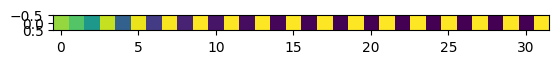

In [9]:
v = _pos_encoding(1, 32)
print(v.shape)
vp = v.numpy()

import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(vp.reshape(1, -1))


torch.Size([32])


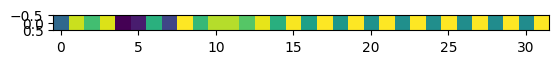

In [13]:
v = _pos_encoding(16, 32)
print(v.shape)
vp = v.numpy()

import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(vp.reshape(1, -1))


torch.Size([32])


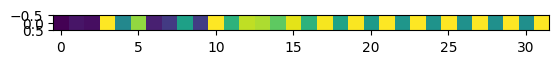

In [14]:
v = _pos_encoding(30, 32)
print(v.shape)
vp = v.numpy()

import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(vp.reshape(1, -1))

In [10]:
# バッチ型の正弦波位置エンコーディング
def pos_encoding(ts, output_dim, device='cpu'):
    batch_size = len(ts)
    v = torch.zeros(batch_size, output_dim, device=device)
    for i in range(batch_size):
        v[i] = _pos_encoding(ts[i], output_dim, device)
    return v

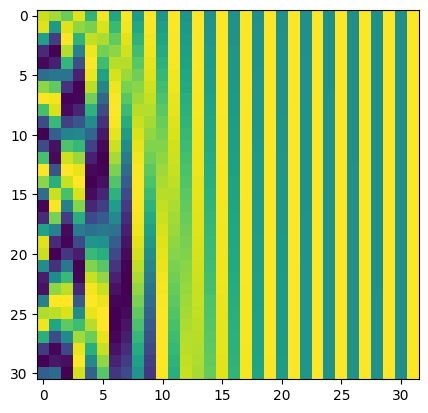

In [12]:
spe = pos_encoding(torch.arange(start=1, end=32, step=1), output_dim=32)
plt.imshow(spe.numpy())